<!-- # %% [markdown] -->
# 1. Generate diffraction simulations


INFO - Prepared 757 orientations.
7108314: 100%|██████████| 757/757 [00:08<00:00, 88.62it/s] 
INFO - Generated 757 patterns.


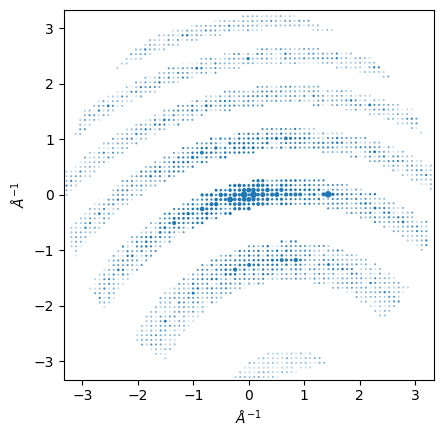

In [2]:
# %%
from pathlib import Path
import logging
import numpy as np

from orix.crystal_map import Phase
from orix.sampling import get_sample_reduced_fundamental
from orix.quaternion import Rotation
from diffsims.generators.simulation_generator import SimulationGenerator
from diffpy.structure import Lattice, Structure
from diffpy.structure.spacegroups import GetSpaceGroup

from parse_pdb_with_scale_remove_h import parse_pdb_with_scale
from compute_B import compute_B

# ── user-tunable parameters ────────────────────────────────────────────────────
# input = "/home/bubl3932/files/simulations/aP_lyso/lyso.pdb"
# input = "/home/bubl3932/files/simulations/cF_Tl2Nb2O7/1000387.cif"
# input = "/home/bubl3932/files/simulations/cI_Fe5O12Y3/1521848.cif"
# input = "/home/bubl3932/files/simulations/cP_LTA/7108314.cif"
# input = "/home/bubl3932/files/simulations/mC_CaMgO6Si2/1000007.cif"
# input = "/home/bubl3932/files/simulations/mP_C3D3O7Sr/1000002.cif"
# input = "/home/bubl3932/files/simulations/oA_CdCl2N2/9008053.cif"
# input = "/home/bubl3932/files/simulations/oC_Cu3O21RbTa7/1001218.cif"
# input = "/home/bubl3932/files/simulations/oF_Si2Ti/1009012.cif"
# input = "/home/bubl3932/files/simulations/oI_GaLiO4Ti/1008839.cif"
# input = "/home/bubl3932/files/simulations/oP_Cd2Zr3/2106134.cif"

# input = "/home/bubl3932/files/simulations/MFM300-VIII_tI/4135627.cif"

# input = "/Users/xiaodong/Desktop/simulations/C3O6Sr_mP/1000003.cif"
# input = "/Users/xiaodong/Desktop/simulations/CuO2_oF/1521320.cif"
# input = "/Users/xiaodong/Desktop/simulations/MFM300-VIII_tI/4135627.cif"
input = "/Users/xiaodong/Desktop/simulations/LTA_cP/7108314.cif"

REF_PATH            = Path(input).expanduser()

# Orientation handling:
# - "sample_fundamental": generate a grid of orientations (your original behavior)
# - "from_sol": read UB matrices from a CrystFEL-style .sol file and convert to rotations
# - "from_npy": load matrices from a .npy file (shape (N,3,3))
# - "manual": set ORIENTATION_MATRICES_MANUAL below (list/array of (N,3,3))
ORIENTATION_SOURCE          = "from_sol"   # "sample_fundamental" | "from_sol" | "from_npy" | "manual"
ORIENTATION_SOL_PATH        = Path("/Users/xiaodong/Desktop/3DED-DATA/LTA/LTA1/XDS_FOLDER/orientations_UB.sol")                   # e.g. "/path/to/orientations.sol"
ORIENTATION_NPY_PATH        = None                   # e.g. "/path/to/orientations.npy"
ORIENTATION_MATRICES_MANUAL = None                   # list/np.ndarray with shape (N,3,3)

# If reading matrices, specify what they are:
# - "UB": matrices are in the same convention as this notebook writes to .sol (UB = B @ R)
# - "R": matrices are pure rotation matrices (crystal -> lab)
ORIENTATION_MATRICES_KIND   = "UB"                   # "UB" | "R"

# For quick tests on rotational datasets: simulate only a subset of frames
FRAME_START = None  # e.g. 0
FRAME_STOP  = None  # e.g. 200

RESOLUTION_DEG      = 10        # only used when ORIENTATION_SOURCE="sample_fundamental"
MAX_RESOLUTION      = 0.3       # max simulated resolution in Å
DIRECT_BEAM         = False     # True = include direct beam, False = exclude direct beam
MAX_EXC_ERR_AINV    = 0.02      # max excitation error (diffsims kinematical)
SHAPE_FACTOR_W_AINV = 0.001     # shape factor. If None set to max excitation error
VOLTAGE_KV          = 300       # accelerating voltage in kV

# Optional: switch on multislice (abTEM) later (HDF5-writing cell supports this)
USE_ABTEM_MULTISLICE = False
ABTEM_THICKNESS_A    = None     # required if USE_ABTEM_MULTISLICE=True (e.g. 500.0 for 50 nm)
# ───────────────────────────────────────────────────────────────────────────────

logging.basicConfig(level=logging.INFO, format="%(levelname)s - %(message)s")


def _slice_mats(mats: np.ndarray) -> np.ndarray:
    if FRAME_START is None and FRAME_STOP is None:
        return mats
    return mats[slice(FRAME_START, FRAME_STOP)]


def read_sol_orientation_matrices(sol_path: Path) -> np.ndarray:
    """
    Read a CrystFEL-style .sol file written by this notebook:
        <h5_path> //<idx> m11 ... m33 0.000 0.000 <bravais>
    Returns: (N, 3, 3) float array of the 9 matrix entries.
    """
    mats = []
    with open(sol_path, "r") as fh:
        for line in fh:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            # Find the 9 consecutive floats that represent the matrix
            floats = []
            for p in parts:
                try:
                    floats.append(float(p))
                except ValueError:
                    continue
            if len(floats) < 9:
                continue
            m = np.array(floats[:9], dtype=float).reshape(3, 3)
            mats.append(m)
    if not mats:
        raise ValueError(f"No orientation matrices found in: {sol_path}")
    return np.stack(mats, axis=0)


# --- load structure as an orix Phase ------------------------------------------
if REF_PATH.suffix == ".pdb":
    cell, sg_sym, atoms = parse_pdb_with_scale(
        REF_PATH, remove_hydrogens=True, include_occupancy=False
    )
    phase = Phase(
        space_group=GetSpaceGroup(sg_sym),
        structure=Structure(atoms, Lattice(*cell))
    )
elif REF_PATH.suffix == ".cif":
    phase = Phase.from_cif(REF_PATH)
else:
    raise ValueError("Unsupported file format. Please provide a .pdb or .cif file.")


# --- construct orientations ----------------------------------------------------
B_mat = compute_B(
    (
        phase.structure.lattice.a,
        phase.structure.lattice.b,
        phase.structure.lattice.c,
        phase.structure.lattice.alpha,
        phase.structure.lattice.beta,
        phase.structure.lattice.gamma,
    )
)
B_inv = np.linalg.inv(B_mat)

if ORIENTATION_SOURCE == "sample_fundamental":
    orientations = get_sample_reduced_fundamental(
        resolution=RESOLUTION_DEG, point_group=phase.point_group
    )

else:
    if ORIENTATION_SOURCE == "from_sol":
        if ORIENTATION_SOL_PATH is None:
            raise ValueError("Set ORIENTATION_SOL_PATH when ORIENTATION_SOURCE='from_sol'")
        mats = read_sol_orientation_matrices(Path(ORIENTATION_SOL_PATH).expanduser())

    elif ORIENTATION_SOURCE == "from_npy":
        if ORIENTATION_NPY_PATH is None:
            raise ValueError("Set ORIENTATION_NPY_PATH when ORIENTATION_SOURCE='from_npy'")
        mats = np.load(Path(ORIENTATION_NPY_PATH).expanduser())
        if mats.ndim != 3 or mats.shape[-2:] != (3, 3):
            raise ValueError("Expected ORIENTATION_NPY_PATH to contain an array of shape (N,3,3)")

    elif ORIENTATION_SOURCE == "manual":
        if ORIENTATION_MATRICES_MANUAL is None:
            raise ValueError("Set ORIENTATION_MATRICES_MANUAL when ORIENTATION_SOURCE='manual'")
        mats = np.asarray(ORIENTATION_MATRICES_MANUAL, dtype=float)
        if mats.ndim != 3 or mats.shape[-2:] != (3, 3):
            raise ValueError("Expected ORIENTATION_MATRICES_MANUAL with shape (N,3,3)")

    else:
        raise ValueError(f"Unknown ORIENTATION_SOURCE: {ORIENTATION_SOURCE}")

    mats = _slice_mats(mats)

    if ORIENTATION_MATRICES_KIND.upper() == "UB":
        # If matrices are UB = B @ R, convert to pure rotations R
        rot_mats = np.einsum("ij,njk->nik", B_inv, mats)
    elif ORIENTATION_MATRICES_KIND.upper() == "R":
        rot_mats = mats
    else:
        raise ValueError("ORIENTATION_MATRICES_KIND must be 'UB' or 'R'")

    orientations = Rotation.from_matrix(rot_mats)

logging.info("Prepared %d orientations.", orientations.size)

# --- diffsims kinematical simulations (used for spot positions + optional images)
# If you only want multislice later, keep this; it’s still useful as a geometry sanity check.
generator = SimulationGenerator(
    accelerating_voltage=VOLTAGE_KV,
    shape_factor_model="atanc",  # "atanc", "sinc", "sin2c", "linear", "lorentzian" is default
    approximate_precession=False,
)

sims = generator.calculate_diffraction2d(
    phase                = phase,
    rotation             = orientations,
    reciprocal_radius    = 1 / MAX_RESOLUTION,
    with_direct_beam     = DIRECT_BEAM,
    max_excitation_error = MAX_EXC_ERR_AINV,
    shape_factor_width   = SHAPE_FACTOR_W_AINV,
    debye_waller_factors = None,
    show_progressbar     = True,
)

sims.plot()
logging.info("Generated %d patterns.", sims.current_size)


<!-- # %% [markdown] -->
# 2. Write simulated patterns into HDF5 and helper files


### Using indexed orientations (rotational data)
If your dataset is already indexed, set `ORIENTATION_SOURCE` to `from_sol`, `from_npy`, or `manual` in the first code cell.
Then the notebook will simulate **one diffraction image per provided orientation**, so you can compare simulated vs experimental frames directly.

To include dynamical (multislice) intensities later, set `USE_ABTEM_MULTISLICE=True` and provide `ABTEM_THICKNESS_A`.

In [3]:
# %%
import h5py
from tqdm import tqdm
import numpy as np

from electron_wavelength import electron_wavelength
from clen_for_resolution import clen_for_dmin
from generate_cell import write_cell_file
from generate_geom import write_geom_file
from calculate_calibration import calculate_calibration
from create_empty_backgrounds import create_empty_backgrounds
from helper_functions_UB import copy_h5_file, get_next_simulation_folder
from compute_B import compute_B

# Optional multislice (abTEM) branch:
# - This cell is written so the notebook still runs without abTEM installed.
# - When enabled, we use abTEM multislice + index_diffraction_spots to get dynamical spot intensities.
#
# References:
# - abTEM multislice + diffraction patterns: https://abtem.readthedocs.io/en/latest/user_guide/walkthrough/multislice.html
# - Thickness series + indexing diffraction spots: https://abtem.readthedocs.io/en/latest/user_guide/examples/notebooks/saed_quickstart.html

# geometry / detector constants (edit if your setup changes)
WAVELENGTH_A       = electron_wavelength(VOLTAGE_KV)
CLEN_M             = clen_for_dmin(MAX_RESOLUTION)   # camera length in meters
PIXELS_PER_M       = 17_857.14285714286             # corresponds to 56 µm/pixel size since 1/17857.14285714286 ≈ 56e-6 m
IN_PLANE_ANGLE_DEG = 180                            # matches .geom definitions
SIGMA_PIX          = 1
FAST_MODE          = False
NORMALISE          = True
FAST_CLIP_TH       = 1e-12
INTENSITY_SCALE    = 10_000

# abTEM multislice parameters (only used when USE_ABTEM_MULTISLICE=True in cell 1)
ABTEM_SAMPLING_A        = 0.05    # real-space sampling [Å]
ABTEM_SLICE_THICKNESS_A = 2.0     # slice thickness [Å]
ABTEM_GPTS              = 512     # real-space grid points (x/y)
ABTEM_PROJECTION        = "infinite"
ABTEM_PARAMETRIZATION   = "lobato"
ABTEM_BLOCK_DIRECT      = DIRECT_BEAM is False  # if you exclude direct beam in output, also block it here
ABTEM_CROP_MRAD         = None    # e.g. 120 (see abTEM docs); None = no crop before indexing
ABTEM_SPOT_I_MIN        = 0.0     # filter out extremely weak spots before rasterizing

# derived paths ----------------------------------------------------------------
n_patterns  = int(orientations.size)

working_dir  = REF_PATH.parent
create_empty_backgrounds(working_dir, n_patterns)
empty_h5     = working_dir / f"{n_patterns}_empty_backgrounds.h5"

sim_folder   = get_next_simulation_folder(working_dir)
sim_folder.mkdir(exist_ok=True)

cell_path    = sim_folder / f"{REF_PATH.stem}.cell"
geom_path    = sim_folder / f"{REF_PATH.stem}.geom"
h5_path      = sim_folder / "sim.h5"
sol_path     = sim_folder / "orientation_matrices.sol"
# -----------------------------------------------------------------------------


def _calibration_from_geometry(wavelength_A: float, clen_m: float, pixels_per_m: float) -> float:
    # reciprocal sampling in 1/Å per pixel
    pixel_size_m = 1.0 / pixels_per_m
    return pixel_size_m / (clen_m * wavelength_A)


def _render_spots_to_image(
    positions_xy_ainv: np.ndarray,
    intensities: np.ndarray,
    shape: tuple[int, int],
    calibration: float,
    beam_pos: tuple[float, float],
    in_plane_angle_deg: float,
    sigma_pix: float,
    intensity_scale: float,
    direct_beam: bool,
) -> np.ndarray:
    """
    Rasterize discrete diffraction spots onto a detector image.

    positions_xy_ainv: (N,2) reciprocal coords in [1/Å]
    intensities:       (N,) spot intensities (arbitrary units)
    calibration:       [1/Å per pixel]
    """
    img = np.zeros(shape, dtype=np.float32)

    # in-plane rotation applied to reciprocal coords before mapping to pixels
    ang = np.deg2rad(in_plane_angle_deg)
    R = np.array([[np.cos(ang), -np.sin(ang)], [np.sin(ang), np.cos(ang)]], dtype=float)

    xy = positions_xy_ainv @ R.T
    px = xy[:, 0] / calibration + beam_pos[1]
    py = xy[:, 1] / calibration + beam_pos[0]

    # draw spots as Gaussian blobs (patch-based for speed)
    if sigma_pix <= 0:
        sigma_pix = 0.5

    rad = int(np.ceil(4 * sigma_pix))
    yy0 = np.arange(-rad, rad + 1)
    xx0 = np.arange(-rad, rad + 1)
    XX, YY = np.meshgrid(xx0, yy0)
    kernel = np.exp(-(XX**2 + YY**2) / (2 * sigma_pix**2)).astype(np.float32)

    for x, y, I in zip(px, py, intensities):
        if I <= ABTEM_SPOT_I_MIN:
            continue
        xi = int(np.round(x))
        yi = int(np.round(y))
        x1, x2 = xi - rad, xi + rad + 1
        y1, y2 = yi - rad, yi + rad + 1
        if x2 <= 0 or y2 <= 0 or x1 >= shape[1] or y1 >= shape[0]:
            continue

        kx1 = max(0, -x1)
        ky1 = max(0, -y1)
        kx2 = kernel.shape[1] - max(0, x2 - shape[1])
        ky2 = kernel.shape[0] - max(0, y2 - shape[0])

        ix1 = max(0, x1)
        iy1 = max(0, y1)
        ix2 = min(shape[1], x2)
        iy2 = min(shape[0], y2)

        img[iy1:iy2, ix1:ix2] += (I * kernel[ky1:ky2, kx1:kx2])

    if direct_beam:
        # add a modest direct beam marker (if your experiment includes it, you may want to scale this up)
        by, bx = int(round(beam_pos[0])), int(round(beam_pos[1]))
        if 0 <= by < shape[0] and 0 <= bx < shape[1]:
            img[by, bx] += img.max() if img.max() > 0 else 1.0

    return (img * intensity_scale).astype(np.float32)


def _abtem_indexed_spots_for_orientation(rotation: Rotation):
    """
    Run abTEM multislice for ONE orientation and return (positions_xy [1/Å], intensities).
    Requires: abTEM + ASE installed.
    """
    try:
        import abtem
        from ase.io import read as ase_read
    except Exception as e:
        raise RuntimeError(
            "abTEM (and ASE) are required when USE_ABTEM_MULTISLICE=True. "
            "Install e.g. with: pip install abTEM ase"
        ) from e

    if ABTEM_THICKNESS_A is None:
        raise ValueError("Set ABTEM_THICKNESS_A in cell 1 when USE_ABTEM_MULTISLICE=True")

    # Load the (conventional) unit cell and create a slab by repeating in z.
    unit_cell = ase_read(str(REF_PATH))

    c0 = float(unit_cell.cell.lengths()[2])
    nz = max(1, int(np.ceil(float(ABTEM_THICKNESS_A) / c0)))
    slab = unit_cell.repeat((1, 1, nz))

    # Rotate both slab and unit_cell so the beam is along +z in the lab frame.
    # NOTE: rotation convention may need a transpose depending on how your indexing exports matrices.
    Rm = rotation.to_matrix().squeeze()  # (3,3)
    slab.set_cell(slab.cell.array @ Rm.T, scale_atoms=True)
    unit_cell.set_cell(unit_cell.cell.array @ Rm.T, scale_atoms=True)

    # Build potential and run multislice with a plane wave.
    potential = abtem.Potential(
        slab,
        gpts=ABTEM_GPTS,
        sampling=ABTEM_SAMPLING_A,
        projection=ABTEM_PROJECTION,
        parametrization=ABTEM_PARAMETRIZATION,
        slice_thickness=ABTEM_SLICE_THICKNESS_A,
    )

    wave = abtem.PlaneWave(energy=float(VOLTAGE_KV) * 1e3)
    exit_waves = wave.multislice(potential)

    # Max angle derived from your chosen max resolution (small-angle approx): theta ≈ lambda * |g|
    max_angle_mrad = 1e3 * float(WAVELENGTH_A) * (1.0 / float(MAX_RESOLUTION))
    dp = exit_waves.diffraction_patterns(max_angle=max_angle_mrad).compute()

    if ABTEM_BLOCK_DIRECT:
        dp = dp.block_direct()

    indexed = dp.index_diffraction_spots(cell=unit_cell.cell)

    # indexed.positions is [1/Å] and indexed.intensities gives corresponding spot intensities
    pos = np.asarray(indexed.positions)
    inten = np.asarray(indexed.intensities)

    # remove the (0,0,0) spot if present and you want to exclude it
    if not DIRECT_BEAM:
        hkls = np.asarray(indexed.miller_indices)
        mask = ~np.all(hkls == 0, axis=1)
        pos = pos[mask]
        inten = inten[mask]

    # keep only up to your reciprocal radius
    g = np.linalg.norm(pos[:, :2], axis=1)
    mask = g <= (1.0 / float(MAX_RESOLUTION))
    pos = pos[mask]
    inten = inten[mask]

    return pos[:, :2], inten


# write helper files ----------------------------------------------------------
centering   = phase.space_group.short_name[0].upper()
if centering == "A" or centering == "C":
    centering = "S"

write_cell_file(
    {
        "lattice_type": phase.space_group.crystal_system.lower(),
        "centering"   : centering,
        "a"           : phase.structure.lattice.a,
        "b"           : phase.structure.lattice.b,
        "c"           : phase.structure.lattice.c,
        "alpha"       : phase.structure.lattice.alpha,
        "beta"        : phase.structure.lattice.beta,
        "gamma"       : phase.structure.lattice.gamma,
    },
    cell_path
)
write_geom_file(geom_path, wavelength=WAVELENGTH_A, clen=CLEN_M, res=PIXELS_PER_M)

copy_h5_file(empty_h5, h5_path)

# Use your existing helper (kept for backward compatibility) but also compute a fallback.
calibration = calculate_calibration(
    wavelength_A=WAVELENGTH_A, clen_m=CLEN_M, res=PIXELS_PER_M
)
calibration_fallback = _calibration_from_geometry(WAVELENGTH_A, CLEN_M, PIXELS_PER_M)

B_mat = compute_B(
    (
        phase.structure.lattice.a,
        phase.structure.lattice.b,
        phase.structure.lattice.c,
        phase.structure.lattice.alpha,
        phase.structure.lattice.beta,
        phase.structure.lattice.gamma,
    )
)

# update HDF5 in-place ---------------------------------------------------------
with h5py.File(h5_path, "r+", libver="latest") as f:
    imgs = f["entry/data/images"]
    ori  = f["entry/data"].require_dataset(
        "simulation_orientation_matrices",
        shape=(imgs.shape[0], 3, 3),
        dtype=float,
    )
    det_shift_x_mm = f["entry"]["data"].require_dataset(
        "det_shift_x_mm",
        shape=(imgs.shape[0],),
        dtype=float,
        fillvalue=0
    )
    det_shift_y_mm = f["entry"]["data"].require_dataset(
        "det_shift_y_mm",
        shape=(imgs.shape[0],),
        dtype=float,
        fillvalue=0
    )

    shape = imgs.shape[-2:]
    beam_pos = (shape[0] // 2, shape[1] // 2)

    # store run metadata as attributes instead of a loose TXT
    meta = f["entry"].attrs
    meta.update(
        ref_file            = str(REF_PATH),
        orientation_source  = ORIENTATION_SOURCE,
        n_patterns          = int(n_patterns),
        max_resolution      = MAX_RESOLUTION,
        direct_beam         = DIRECT_BEAM,
        beam_position       = beam_pos,
        voltage_kV          = VOLTAGE_KV,
        wavelength_A        = WAVELENGTH_A,
        clen_m              = CLEN_M,
        pixels_per_m        = PIXELS_PER_M,
        calibration         = float(calibration),
        calibration_fallback= float(calibration_fallback),
        in_plane_angle_deg  = IN_PLANE_ANGLE_DEG,
        sigma_pix           = SIGMA_PIX,
        intensity_scale     = INTENSITY_SCALE,
        use_abtem_multislice= bool(USE_ABTEM_MULTISLICE),
        abtem_thickness_A   = float(ABTEM_THICKNESS_A) if ABTEM_THICKNESS_A is not None else -1.0,
        max_excitation_err  = MAX_EXC_ERR_AINV,
        shape_factor_width  = SHAPE_FACTOR_W_AINV,
    )

    for i in tqdm(range(imgs.shape[0]), desc="Writing patterns"):
        if USE_ABTEM_MULTISLICE:
            # Dynamical spot intensities via abTEM, rasterized to your detector geometry
            pos_xy, inten = _abtem_indexed_spots_for_orientation(orientations[i])
            pattern = _render_spots_to_image(
                positions_xy_ainv=pos_xy,
                intensities=inten,
                shape=shape,
                calibration=float(calibration),
                beam_pos=beam_pos,
                in_plane_angle_deg=IN_PLANE_ANGLE_DEG,
                sigma_pix=SIGMA_PIX,
                intensity_scale=1.0,   # scaling handled below
                direct_beam=DIRECT_BEAM
            )
        else:
            # Original kinematical diffsims path
            pattern = sims.irot[i].get_diffraction_pattern(
                shape                = shape,
                direct_beam_position = beam_pos,
                in_plane_angle       = IN_PLANE_ANGLE_DEG,
                sigma                = SIGMA_PIX,
                calibration          = calibration,
                fast                 = FAST_MODE,
                normalize            = NORMALISE,
                fast_clip_threshold  = FAST_CLIP_TH,
            )

        imgs[i] += (pattern * INTENSITY_SCALE).astype(imgs.dtype)
        ori[i]   = B_mat @ orientations[i].to_matrix().squeeze()

# write .sol -------------------------------------------------------------------

LAT_CODE = {
    'triclinic':'a','monoclinic':'m','orthorhombic':'o',
    'tetragonal':'t','rhombohedral':'h','hexagonal':'h','cubic':'c'
}

AXIS_MAP = {
    'monoclinic':    'b',
    'tetragonal':    'c',
    'hexagonal':     'c',
    'trigonal':      'c',
    'rhombohedral':  'c',
    # orthorhombic, cubic, triclinic → no unique_axis entry
}

unique = AXIS_MAP.get(phase.space_group.crystal_system.lower())
if unique:
    bravais = f"{LAT_CODE[phase.space_group.crystal_system.lower()]}{centering}{unique}"
else:
    bravais = f"{LAT_CODE[phase.space_group.crystal_system.lower()]}{centering}"

with h5py.File(h5_path, "r") as fh:
    ori = fh["entry/data/simulation_orientation_matrices"][:]  # ← ndarray copy

with open(sol_path, "w") as fh:
    for idx, m in enumerate(ori):
        line = " ".join(f"{v:+.7f}" for v in m.flatten())
        fh.write(f"{h5_path} //{idx} {line} 0.000 0.000 {bravais}\n")

logging.info("All files written to %s", sim_folder)


→ Wrote /Users/xiaodong/Desktop/simulations/LTA_cP/sim_001/7108314.cell
→ Wrote /Users/xiaodong/Desktop/simulations/LTA_cP/sim_001/7108314.geom


Writing patterns: 100%|██████████| 757/757 [00:32<00:00, 23.53it/s]
INFO - All files written to /Users/xiaodong/Desktop/simulations/LTA_cP/sim_001


<!-- # %% [markdown] -->
# 3. Run Gandalf integration from the generated .sol


In [ ]:
# %%
from gandalf_iterator import gandalf_iterator

extra_flags = [
    "--no-revalidate", "--no-half-pixel-shift",
    "--peaks=peakfinder9",
    "--indexing=file", f"--fromfile-input-file={sol_path}",
    "--no-check-cell", "--no-check-peaks", "--no-retry", "--no-refine",
    "--integration=rings", "--int-radius=4,5,7",
    "--no-non-hits-in-stream", "--fix-profile-radius=70000000",
]
cell_path = str(cell_path)
geom_path = str(geom_path)
gandalf_iterator(
    geomfile_path       = geom_path,
    cellfile_path       = cell_path,
    input_path          = sim_folder,
    output_file_base    = "from_file",
    num_threads         = 24,
    x                   = 512.5,   # beam centre in pixels
    y                   = 512.5,
    step                = 0.5,
    layers              = 0,
    extra_flags         = extra_flags,
)
logging.info("Gandalf integration finished.")
